In [ ]:
import sys, json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import torch
from rdkit import Chem
from rdkit.Chem import Draw
import statistics

def find_project_root(marker=".git") -> Path:
    path = Path.cwd()
    for parent in [path, *path.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not find project root (no {marker} found)")

project_root = find_project_root()
sys.path.append(str(project_root))

from src.sample import generate_molecules
from src.evaluate import (
    compute_validity, compute_uniqueness, compute_novelty, scaffold_breakdown,
    compute_qed_scores, compute_scaffold_novelty_rate, compute_scaffold_holdout_rate
)

In [ ]:
model_name = "char_lstm_0804_160242"

tokenization = "char_tokenized" # "char_tokenized" or "atom_tokenized"

In [ ]:
data_dir = project_root / "data" / "processed"
results_dir = project_root / "results"
results_dir.mkdir(parents=True, exist_ok=True)

with open(data_dir / tokenization / "canonical_training_smiles.json") as f:
    canonical_training_set = set(json.load(f))

with open(data_dir / "holdout_scaffolds.json") as f:
    holdout_scaffolds = set(json.load(f))

with open(data_dir / tokenization / "training_scaffolds.json") as f:
    train_scaffolds = set(json.load(f))

df = pd.read_csv(project_root / "data" / "zinc250k.csv")

model_path = project_root / "models" / f"{model_name}.th"

In [17]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA")
elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")
    print("Using MPS")
else:
    print("CUDA not available, using CPU")
    device = torch.device("cpu")

Using CUDA


In [18]:
temperatures = [0.7, 1.0, 1.3]
results = []
generated_by_temp = {}  # keep the raw output around for the molecule-rendering step later


for temp in temperatures:
    generated = generate_molecules(
        num_samples=5000, model_path=model_path,
        batch_size=256, device=device, temperature=temp,
    )
    generated_by_temp[temp] = generated

    valid_smiles, invalid_count = compute_validity(generated)
    validity_rate = len(valid_smiles) / len(generated)
    uniqueness_rate = compute_uniqueness(valid_smiles)

    unique_valid_smiles = list(set(valid_smiles))
    if unique_valid_smiles:
        novel, not_novel, novelty_rate = compute_novelty(canonical_training_set, unique_valid_smiles)
        breakdown = scaffold_breakdown(unique_valid_smiles, train_scaffolds, holdout_scaffolds)
        scaffold_novelty_rate = compute_scaffold_novelty_rate(breakdown)
        scaffold_holdout_rate = compute_scaffold_holdout_rate(breakdown)
    else:
        novelty_rate = scaffold_novelty_rate = scaffold_holdout_rate = 0.0

    qed_scores = compute_qed_scores(valid_smiles)
        
    results.append({
        "temperature": temp,
        "validity rate": validity_rate,
        "uniqueness rate": uniqueness_rate,
        "novelty rate": novelty_rate,
        "scaffold novelty rate": scaffold_novelty_rate,
        "scaffold holdout rate": scaffold_holdout_rate,
        "n_generated": len(generated),
        "n_valid": len(valid_smiles),
        "mean_qed_generated": statistics.mean(qed_scores),
        "mean_qed_real": df["qed"].mean(),
        "median_qed_generated": statistics.median(qed_scores),
    })

results_df = pd.DataFrame(results)
results_df.to_csv(results_dir / f"{model_name}_metrics.csv", index=False)
results_df

[21:08:11] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 16 17 18
[21:08:11] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 16 17 18
[21:08:11] Can't kekulize mol.  Unkekulized atoms: 14 15 16 17 19
[21:08:11] Can't kekulize mol.  Unkekulized atoms: 14 15 16 17 19
[21:08:11] Can't kekulize mol.  Unkekulized atoms: 1 2 3 6 7 23 26
[21:08:11] Can't kekulize mol.  Unkekulized atoms: 1 2 3 6 7 23 26
[21:08:11] Can't kekulize mol.  Unkekulized atoms: 9 10 11 12 16
[21:08:11] Can't kekulize mol.  Unkekulized atoms: 9 10 11 12 16
[21:08:11] SMILES Parse Error: unclosed ring for input: 'C[C@@H](SC1=NC(=O)[C@@H]2C(=N1)c1ccccc1CC2)C(=O)Nc1ccc(S(N)(=O)=O)cc'
[21:08:11] Can't kekulize mol.  Unkekulized atoms: 9 10 12 13 15 16 18
[21:08:11] Can't kekulize mol.  Unkekulized atoms: 9 10 12 13 15 16 18
[21:08:11] SMILES Parse Error: extra open parentheses while parsing: CN(C)c1ccc([C@@H]2Nc3c(c(C(F)(F)F)nc4c(Cl)cccc34)=NC2=O)c(OCC(=O)NC2
[21:08:11] SMILES Parse Error: check for mistakes around posi

,temperature,validity rate,uniqueness rate,novelty rate,scaffold novelty rate,scaffold holdout rate,n_generated,n_valid,mean_qed_generated,mean_qed_real,median_qed_generated
0,0.7,0.9802,0.999592,0.996938,0.477648,0.089406,5000,4901,0.762936,0.728264,0.789328
1,1.0,0.9190,1.000000,0.998477,0.614363,0.072252,5000,4595,0.731152,0.728264,0.757219
2,1.3,0.7706,1.000000,0.998443,0.708020,0.051648,5000,3853,0.688312,0.728264,0.712729


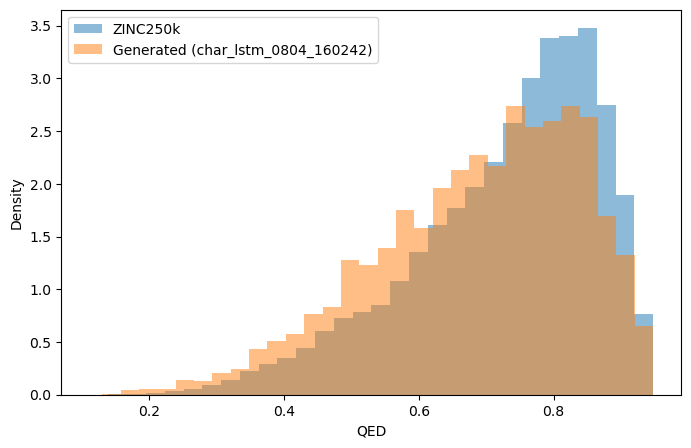

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["qed"], bins=30, alpha=0.5, label="ZINC250k", density=True)
ax.hist(qed_scores, bins=30, alpha=0.5, label=f"Generated ({model_name})", density=True)
ax.legend()
ax.set_xlabel("QED")
ax.set_ylabel("Density")
plt.show()
fig.savefig(results_dir / f"{model_name}_qed_comparison.png", dpi=200, bbox_inches="tight")

In [20]:
breakdown

training_scaffold_qed_scores = compute_qed_scores(breakdown['train_scaffold_matches'])
holdout_scaffold_qed_scores = compute_qed_scores(breakdown['holdout_scaffold_matches'])
outside_dataset_scaffold_qed_scores = compute_qed_scores(breakdown['outside_dataset_scaffolds'])

print(f"Training Scaffold Generated QED Mean: {statistics.mean(training_scaffold_qed_scores)}")
print(f"Holdout Scaffold Generated QED Mean: {statistics.mean(holdout_scaffold_qed_scores)}")
print(f"Outside Dataset Scaffold Genereted QED Mean: {statistics.mean(outside_dataset_scaffold_qed_scores)}")

Training Scaffold Generated QED Mean: 0.6984178124038991
Holdout Scaffold Generated QED Mean: 0.7143010042158354
Outside Dataset Scaffold Genereted QED Mean: 0.6817714093677703
